# 04 — Modeling RH: Personas (Clusterização)

**Objetivo:** identificar grupos (personas) de colaboradores com base em características comportamentais/demográficas, **sem usar a target `Rotatividade`**.

Entradas:
- `data/processed/X_cluster.parquet`
- (opcional) `data/interim/rh_joined.csv` para interpretar clusters no dado original

Saídas:
- `data/processed/rh_with_clusters.csv`
- `artifacts/kmeans.pkl` (ou gmm)
- `artifacts/pca.pkl`


### 4.1 Setup

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


### 4.2 Load (processed + interim)

In [2]:
DATA_PROCESSED = Path("../data/processed")
DATA_INTERIM = Path("../data/interim")
ARTIFACTS = Path("../artifacts")

X = pd.read_parquet(DATA_PROCESSED / "X_cluster.parquet")
df_raw = pd.read_csv(DATA_INTERIM / "rh_joined.csv")

X.shape, df_raw.shape

((4410, 40), (4410, 29))

### 4.3 Redução de dimensionalidade (PCA)

Usamos PCA para facilitar clusterização e visualização.


In [3]:
pca = PCA(n_components=0.80, random_state=RANDOM_STATE)
X_red = pca.fit_transform(X)

X_red.shape

(4410, 15)

In [4]:
joblib.dump(pca, ARTIFACTS / "pca.pkl")
print("OK ->", ARTIFACTS / "pca.pkl")

OK -> ..\artifacts\pca.pkl


### 4.4 Escolha de K (Silhouette)

Teste rápido de 2 a 10 clusters.


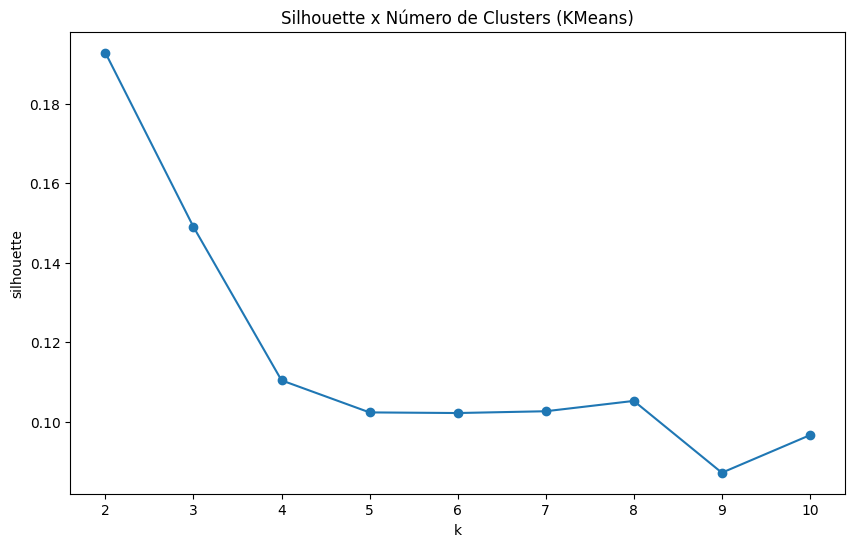

(2, 0.1927995843113377)

In [5]:
scores=[]
ks=range(2,11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(X_red)
    s = silhouette_score(X_red, labels)
    scores.append(s)

plt.figure(figsize=(10,6))
plt.plot(list(ks), scores, marker="o")
plt.title("Silhouette x Número de Clusters (KMeans)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.show()

best_k = int(list(ks)[int(np.argmax(scores))])
best_k, max(scores)

### 4.5 Treino do modelo (KMeans)

Ajuste `k` se você quiser comparar com a interpretação de negócio.


In [6]:
k = best_k  # ajuste manual se necessário
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
labels = kmeans.fit_predict(X_red)

joblib.dump(kmeans, ARTIFACTS / "kmeans.pkl")
print("OK ->", ARTIFACTS / "kmeans.pkl")

pd.Series(labels).value_counts().sort_index()

OK -> ..\artifacts\kmeans.pkl


0    3243
1    1167
Name: count, dtype: int64

### 4.6 Análise e interpretação dos clusters

Aqui voltamos ao dataset original para entender o perfil de cada cluster.


In [7]:
df_clusters = df_raw.copy()
df_clusters["Cluster"] = labels
df_clusters.head()

,Idade,Rotatividade,ViagensDeNegocio,Departamento,DistanciaDeCasa,Educacao,CampoDeEducacao,ContagemDeEmpregados,IDDoEmpregado,Genero,NivelDoCargo,Funcao,EstadoCivil,RendaMensal,NumeroDeEmpresas,MaiorDe18,AumentoPercentualSalario,HorasPadrao,NivelDeOpcaoDeCompraDeAcoes,TotalDeAnosTrabalhados,TreinamentosNoUltimoAno,AnosNaEmpresa,AnosDesdeUltimaPromocao,AnosComAtualGestor,SatisfacaoComAmbiente,SatisfacaoNoTrabalho,EquilibrioTrabalhoVida,EnvolvimentoNoTrabalho,AvaliacaoDeDesempenho,Cluster
0,51,Nao,Viagens_Raras,Vendas,6,2,Ciências da Vida,1,1,Feminino,1,Representante de Saúde,Casado(a),26232.0,1.0,Y,11,8,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3,0
1,31,Sim,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,10,1,Ciências da Vida,1,2,Feminino,1,Cientista de Pesquisa,Solteiro(a),8378.0,0.0,Y,23,8,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4,0
2,32,Nao,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,17,4,Outro,1,3,Masculino,4,Executivo de Vendas,Casado(a),38656.0,1.0,Y,15,8,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3,0
3,38,Nao,Nao_Viaja,Pesquisa_e_Desenvolvimento,2,5,Ciências da Vida,1,4,Masculino,3,Recursos Humanos,Casado(a),16642.0,3.0,Y,11,8,3,13.0,5,8,7,5,4.0,4.0,3.0,2,3,1
4,32,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,10,1,Médica,1,5,Masculino,1,Executivo de Vendas,Solteiro(a),4684.0,4.0,Y,12,8,2,9.0,2,6,0,4,4.0,1.0,3.0,3,3,0


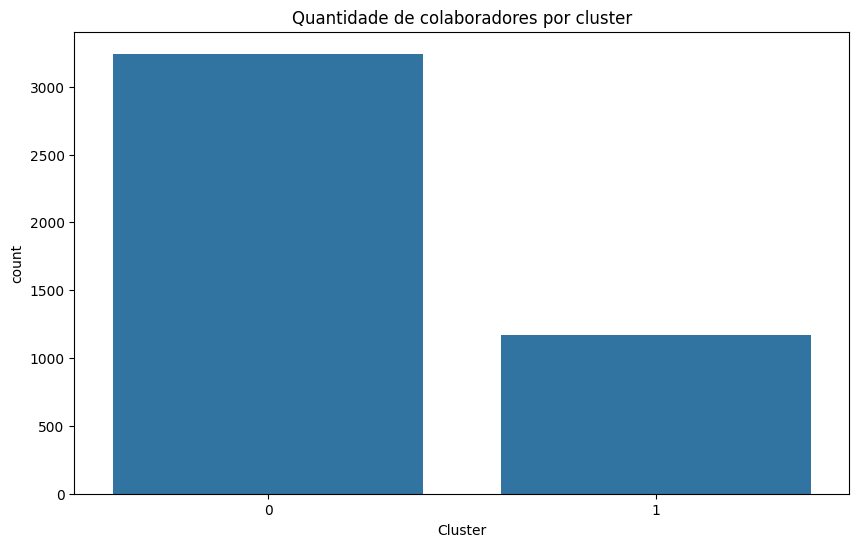

In [9]:
# Distribuição de clusters
plt.figure(figsize=(10,6))
sns.countplot(data=df_clusters, x="Cluster")
plt.title("Quantidade de colaboradores por cluster")
plt.show()

### 4.6.1 Rotatividade por cluster (apenas para leitura, NÃO para treinar)

Isso ajuda a verificar se algum cluster tem maior risco.


In [10]:
if "Rotatividade" in df_clusters.columns:
    rot_by_cluster = (pd.crosstab(df_clusters["Cluster"], df_clusters["Rotatividade"], normalize="index")*100).round(1)
    rot_by_cluster

### 4.6.2 Resumo numérico por cluster

Ajuste `num_cols` conforme seu dataset.


In [11]:
# Heurística: numéricas no dataset original
num_cols_raw = df_clusters.select_dtypes(include=[np.number]).columns
summary_num = df_clusters.groupby("Cluster")[num_cols_raw].median().T
summary_num.head(30)

Cluster,0,1
Idade,34.0,40.0
DistanciaDeCasa,7.0,7.0
Educacao,3.0,3.0
ContagemDeEmpregados,1.0,1.0
IDDoEmpregado,2216.0,2179.0
NivelDoCargo,2.0,2.0
RendaMensal,9700.0,10590.0
NumeroDeEmpresas,2.0,1.0
AumentoPercentualSalario,14.0,14.0
HorasPadrao,8.0,8.0


### 4.6.3 Resumo categórico por cluster (top categorias)


In [18]:
cat_cols_raw = df_clusters.select_dtypes(include="str").columns

def top_cat(df, col, topn=5):
    return (df[col].value_counts(normalize=True).head(topn)*100).round(1)

examples = {}
for col in list(cat_cols_raw)[:10]:  # mostre só algumas; aumente se quiser
    if col not in ["Rotatividade"]:
        examples[col] = df_clusters.groupby("Cluster").apply(lambda g: top_cat(g, col)).unstack(fill_value=0)

examples

{'ViagensDeNegocio': ViagensDeNegocio    Cluster
 Viagens_Raras       0          71.2
                     1          70.2
 Viagens_Frequentes  0          18.9
                     1          18.8
 Nao_Viaja           0           9.9
                     1          11.1
 dtype: float64,
 'Departamento': Departamento                Cluster
 Pesquisa_e_Desenvolvimento  0          65.3
                             1          65.6
 Vendas                      0          30.0
                             1          31.4
 Recursos_Humanos            0           4.7
                             1           3.1
 dtype: float64,
 'CampoDeEducacao': CampoDeEducacao   Cluster
 Ciências da Vida  0          41.6
                   1          40.1
 Médica            0          31.1
                   1          32.9
 Marketing         0          10.6
                   1          11.3
 Grau Técnico      0           8.7
                   1           9.8
 Outro             0           5.7
           

### 4.7 Persistência do dataset com clusters

In [19]:
out = DATA_PROCESSED / "rh_with_clusters.csv"
df_clusters.to_csv(out, index=False)
print("OK ->", out)

OK -> ..\data\processed\rh_with_clusters.csv


### 4.8 Conclusão

- Clusters gerados e interpretados
- Próximo notebook: **04_modeling_rh_attrition.ipynb** para probabilidade de rotatividade
